**Description**

This notebook performs exploratory data analysis (EDA) and data cleaning on Dune API data for Balancer LBP (Liquidity Bootstrapping Pool) version 1 and 2 datasets. The notebook loads the training dataset, analyzes data distributions and correlations, identifies missing values and outliers, performs data preprocessing (feature engineering, scaling, encoding), and splits the cleaned data into training and test sets (X_train, X_test, y_train, y_test) for machine learning model development.


# Imports


In [1]:
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import training dataset


In [12]:
training_dataset_df = pd.read_csv('../../media/ML/training_dataset.csv')
training_dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 961 entries, 0 to 960
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   chain                 961 non-null    object 
 1   duration_hours        961 non-null    float64
 2   start_weight_proj     961 non-null    float64
 3   end_weight_proj       961 non-null    float64
 4   start_weight_reserve  961 non-null    float64
 5   end_weight_reserve    961 non-null    float64
 6   weight_slope          961 non-null    float64
 7   swap_fee_pct          961 non-null    float64
 8   collateral_is_stable  961 non-null    float64
 9   is_weekend            961 non-null    int64  
 10  weekend_pct           961 non-null    float64
 11  final_success_score   961 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 90.2+ KB


# Data distribution and correlation


--- 1. Checking Target Distribution ---


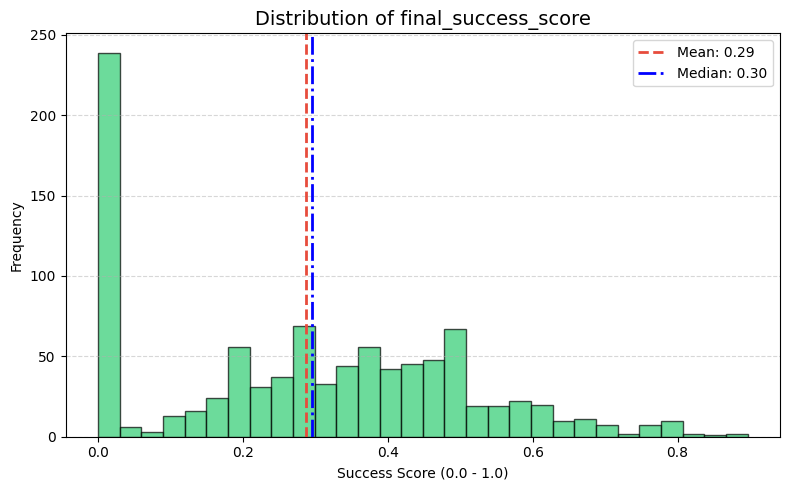

--- 2. Checking Feature Distributions ---


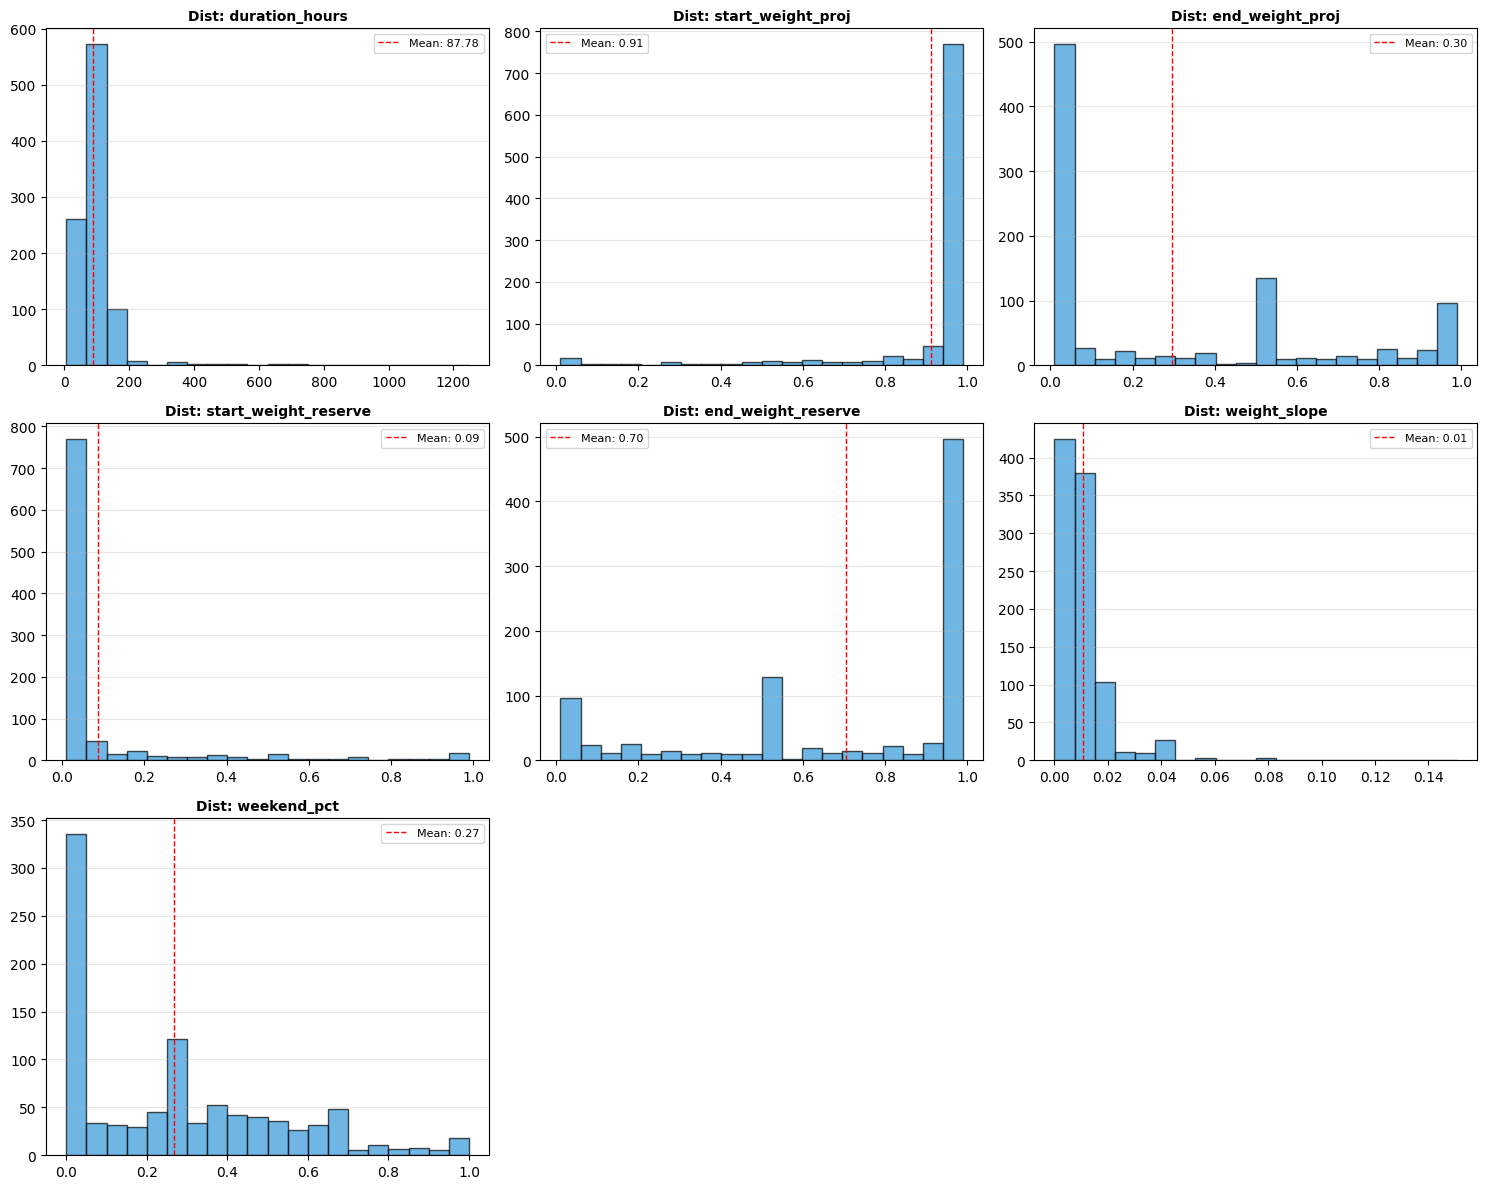

--- 3. Checking Correlations (Scatter Plots) ---


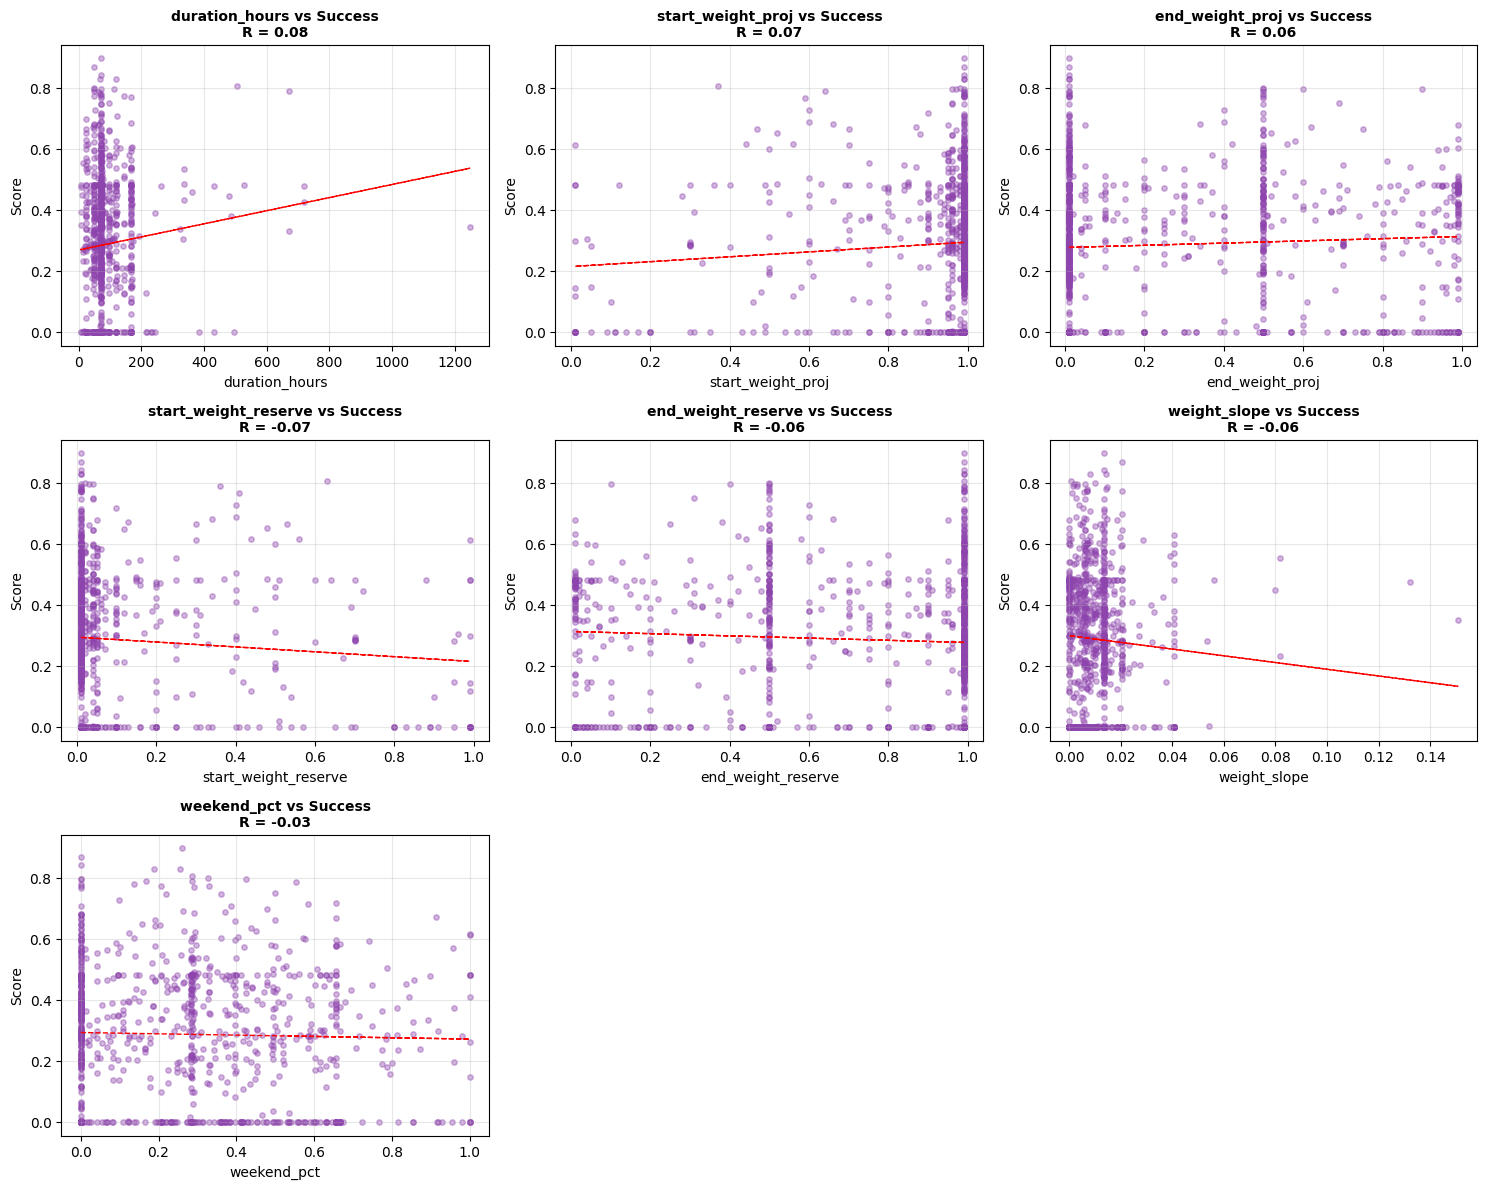

In [7]:
# 1. Define Features (Exclude the Target from the inputs list)
target_col = 'final_success_score'
numerical_features = training_dataset_df.select_dtypes(
    include=['float64', 'int64']).drop(columns=['swap_fee_pct','collateral_is_stable','is_weekend']).columns.tolist()
if target_col in numerical_features:
    numerical_features.remove(target_col)

# ==========================================
# PLOT 1: Target Distribution (Histogram)
# ==========================================


def plot_target_distribution(df, target_col='final_success_score'):
    plt.figure(figsize=(8, 5))

    # Plot Histogram
    counts, bins, patches = plt.hist(
        df[target_col], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)

    # Add Mean and Median lines
    mean_val = df[target_col].mean()
    median_val = df[target_col].median()
    plt.axvline(mean_val, color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='blue', linestyle='-.',
                linewidth=2, label=f'Median: {median_val:.2f}')

    plt.title(f'Distribution of {target_col}', fontsize=14)
    plt.ylabel('Frequency')
    plt.xlabel('Success Score (0.0 - 1.0)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ==========================================
# PLOT 2: Feature Distributions (Unchanged)
# ==========================================


def plot_numerical_distributions(df, features):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]

        # Plot histogram
        ax.hist(df[col], bins=20, color='#3498db',
                edgecolor='black', alpha=0.7)

        # Add mean line
        mean_val = df[col].mean()
        ax.axvline(mean_val, color='red', linestyle='dashed',
                   linewidth=1, label=f'Mean: {mean_val:.2f}')

        ax.set_title(f'Dist: {col}', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# PLOT 3: Feature vs Success (Scatter)
# ==========================================


def plot_feature_vs_success(df, features, target='final_success_score'):
    n_cols = 3
    n_rows = math.ceil(len(features) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        ax = axes[i]

        # Calculate Correlation
        corr = df[col].corr(df[target])

        # Scatter Plot
        ax.scatter(df[col], df[target], alpha=0.4, color='#8e44ad', s=15)

        # Add Trend Line (Linear Regression)
        if len(df[col].unique()) > 1:  # Avoid error on constant features
            m, b = np.polyfit(df[col], df[target], 1)
            ax.plot(df[col], m*df[col] + b, color='red',
                    linewidth=1, linestyle='--')

        ax.set_title(f'{col} vs Success\nR = {corr:.2f}',
                     fontsize=10, fontweight='bold')
        ax.set_ylabel('Score')
        ax.set_xlabel(col)
        ax.grid(True, alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# ==========================================
# EXECUTION
# ==========================================
plt.style.use('fast')

print("--- 1. Checking Target Distribution ---")
plot_target_distribution(training_dataset_df)

print("--- 2. Checking Feature Distributions ---")
plot_numerical_distributions(training_dataset_df, numerical_features)

print("--- 3. Checking Correlations (Scatter Plots) ---")
plot_feature_vs_success(training_dataset_df, numerical_features)

--- 1. Checking Correlations ---


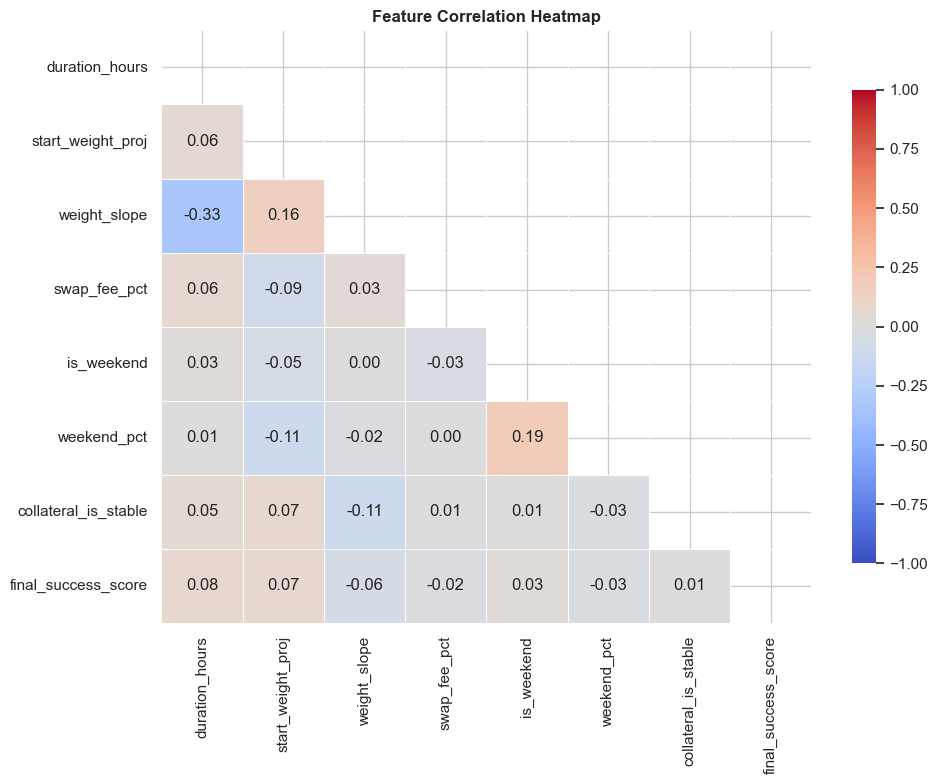

--- 3. Checking Build Parameters ---


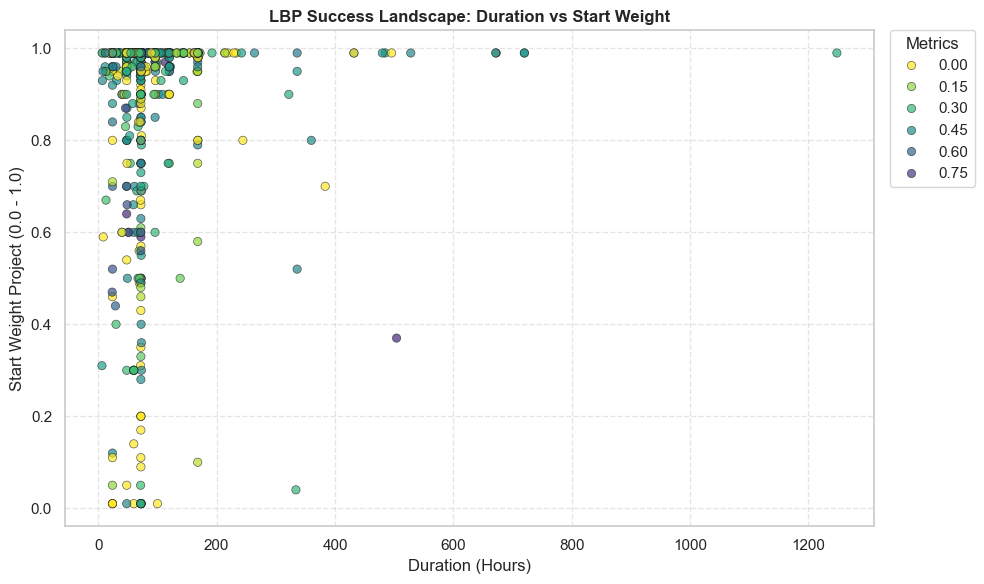

In [14]:
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Correlation Matrix (Updated Columns)
# ---------------------------------------------------------


def plot_correlation_matrix(df):
    # Select columns available in your new dataset
    cols_to_check = [
        'duration_hours',
        'start_weight_proj',
        'weight_slope',          # New feature
        'swap_fee_pct',
        'is_weekend',
        'weekend_pct',
        'collateral_is_stable',
        'final_success_score'    # The Target
    ]

    # Filter only columns that actually exist in the dataframe
    valid_cols = [c for c in cols_to_check if c in df.columns]
    corr = df[valid_cols].corr()

    plt.figure(figsize=(10, 8))

    # Heatmap with masking
    # We remove the hard threshold (0.3) to see all subtle relationships in regression
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
                mask=mask, vmin=-1, vmax=1, center=0,
                linewidths=0.5, cbar_kws={"shrink": .8})

    plt.title('Feature Correlation Heatmap', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. Configuration "Sweet Spot" (Landscape)
# ---------------------------------------------------------


def plot_config_landscape(df):
    plt.figure(figsize=(10, 6))

    # X: Duration, Y: Start Weight
    # Color: Success Score (Gradient)
    # Size: Liquidity (To show "Big" vs "Small" pools)

    # Handle liquidity size scaling safely
    size_col = 'initial_liquidity_usd'
    if size_col not in df.columns:
        size_col = None

    scatter = sns.scatterplot(
        data=df,
        x='duration_hours',
        y='start_weight_proj',
        hue='final_success_score',
        # Purple (High Success) to Yellow (Low) - Reverse for visibility
        palette='viridis_r',
        size=size_col,
        sizes=(20, 300),
        alpha=0.7,
        edgecolor='k'
    )

    plt.title('LBP Success Landscape: Duration vs Start Weight',
              fontsize=12, fontweight='bold')
    plt.xlabel('Duration (Hours)')
    plt.ylabel('Start Weight Project (0.0 - 1.0)')

    # Move legend outside
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
               borderaxespad=0, title="Metrics")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Execution
# ---------------------------------------------------------
# Ensure you pass the merged dataframe (Table A + Table B columns)
print("--- 1. Checking Correlations ---")
plot_correlation_matrix(training_dataset_df)

print("--- 3. Checking Build Parameters ---")
plot_config_landscape(training_dataset_df)

# Data cleaning


In [ ]:
# ==============================================================================
# CONFIGURATION
# ==============================================================================
OUTPUT_X_TRAIN = "X_train.csv"
OUTPUT_X_TEST = "X_test.csv"
OUTPUT_Y_TRAIN = "y_train.csv"
OUTPUT_Y_TEST = "y_test.csv"

# ==============================================================================
# PREPROCESSING LOGIC
# ==============================================================================


def load_and_preprocess(df):
    print("🚀 Starting Data Preprocessing Pipeline...")

    # 1. LOAD DATA
    # ---------------------------------------------------------
    try:
        print(f"   Loaded dataset: {df.shape}")
    except FileNotFoundError:
        print("❌ Error: training_dataset.csv not found.")
        return

    # 2. DROP REDUNDANT COLUMNS
    # ---------------------------------------------------------
    # Reserve weights are 1.0 - Project Weight. They add 0 new info.
    cols_to_drop = ['start_weight_reserve', 'end_weight_reserve']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    print("   ✂️  Dropped redundant reserve weight columns.")

    # 3. HANDLE OUTLIERS (Capping / Winsorization)
    # ---------------------------------------------------------
    # We do NOT drop rows because N=961 is small. We Cap at 1st and 99th percentiles.
    numerical_cols = ['duration_hours', 'weight_slope', 'swap_fee_pct']

    print("   🧢 Capping outliers (1st - 99th percentile)...")
    for col in numerical_cols:
        if col in df.columns:
            lower = df[col].quantile(0.01)
            upper = df[col].quantile(0.99)
            df[col] = np.clip(df[col], lower, upper)

    # 4. CATEGORICAL ENCODING (One-Hot)
    # ---------------------------------------------------------
    # Convert ''chain'' (Ethereum, Arbitrum) into binary columns
    if 'chain' in df.columns:
        print("   🔠 Encoding 'chain' column...")
        df = pd.get_dummies(df, columns=['chain'], prefix='chain', dtype=int)

    # 5. FEATURE SCALING (Standardization)
    # ---------------------------------------------------------
    # Scale continuous variables to have Mean=0 and StdDev=1
    # We skip binary columns (is_weekend, collateral_is_stable)
    scale_cols = [
        'duration_hours', 'start_weight_proj', 'end_weight_proj',
        'weight_slope', 'swap_fee_pct', 'weekend_pct'
    ]

    # Ensure columns exist before scaling
    scale_cols = [c for c in scale_cols if c in df.columns]

    scaler = StandardScaler()
    df[scale_cols] = scaler.fit_transform(df[scale_cols])
    print(f"   ⚖️  Scaled {len(scale_cols)} numerical features.")

    # 6. SPLIT (Train / Test)
    # ---------------------------------------------------------
    # Identify Target and Features
    target_col = 'final_success_score'

    if target_col not in df.columns:
        print("❌ Error: Target column 'final_success_score' not found.")
        return

    X = df.drop(columns=[target_col])  # Drop IDs
    y = df[target_col]

    # Split 80% Train, 20% Test
    print("Splitting Data (80% Train / 20% Test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 7. SAVE ARTIFACTS
    # ---------------------------------------------------------
    X_train.to_csv(OUTPUT_X_TRAIN, index=False)
    X_test.to_csv(OUTPUT_X_TEST, index=False)
    y_train.to_csv(OUTPUT_Y_TRAIN, index=False)
    y_test.to_csv(OUTPUT_Y_TEST, index=False)

    print(f"\n🎉 Preprocessing Complete!")
    print(f"   Training Data: {X_train.shape}")
    print(f"   Test Data:     {X_test.shape}")
    print(f"   Features:      {list(X_train.columns)}")


if __name__ == "__main__":
    load_and_preprocess(training_dataset_df)